In [17]:
from surya.detection import DetectionPredictor
from surya.foundation import FoundationPredictor
from surya.settings import settings
from PIL import Image

dp = DetectionPredictor(checkpoint=settings.DETECTOR_MODEL_CHECKPOINT)

In [18]:
pdf_path = 'rlbook2020.pdf'
from pathlib import Path
Path(pdf_path).exists()

True

In [19]:
import torch
print(torch.cuda.is_available())

True


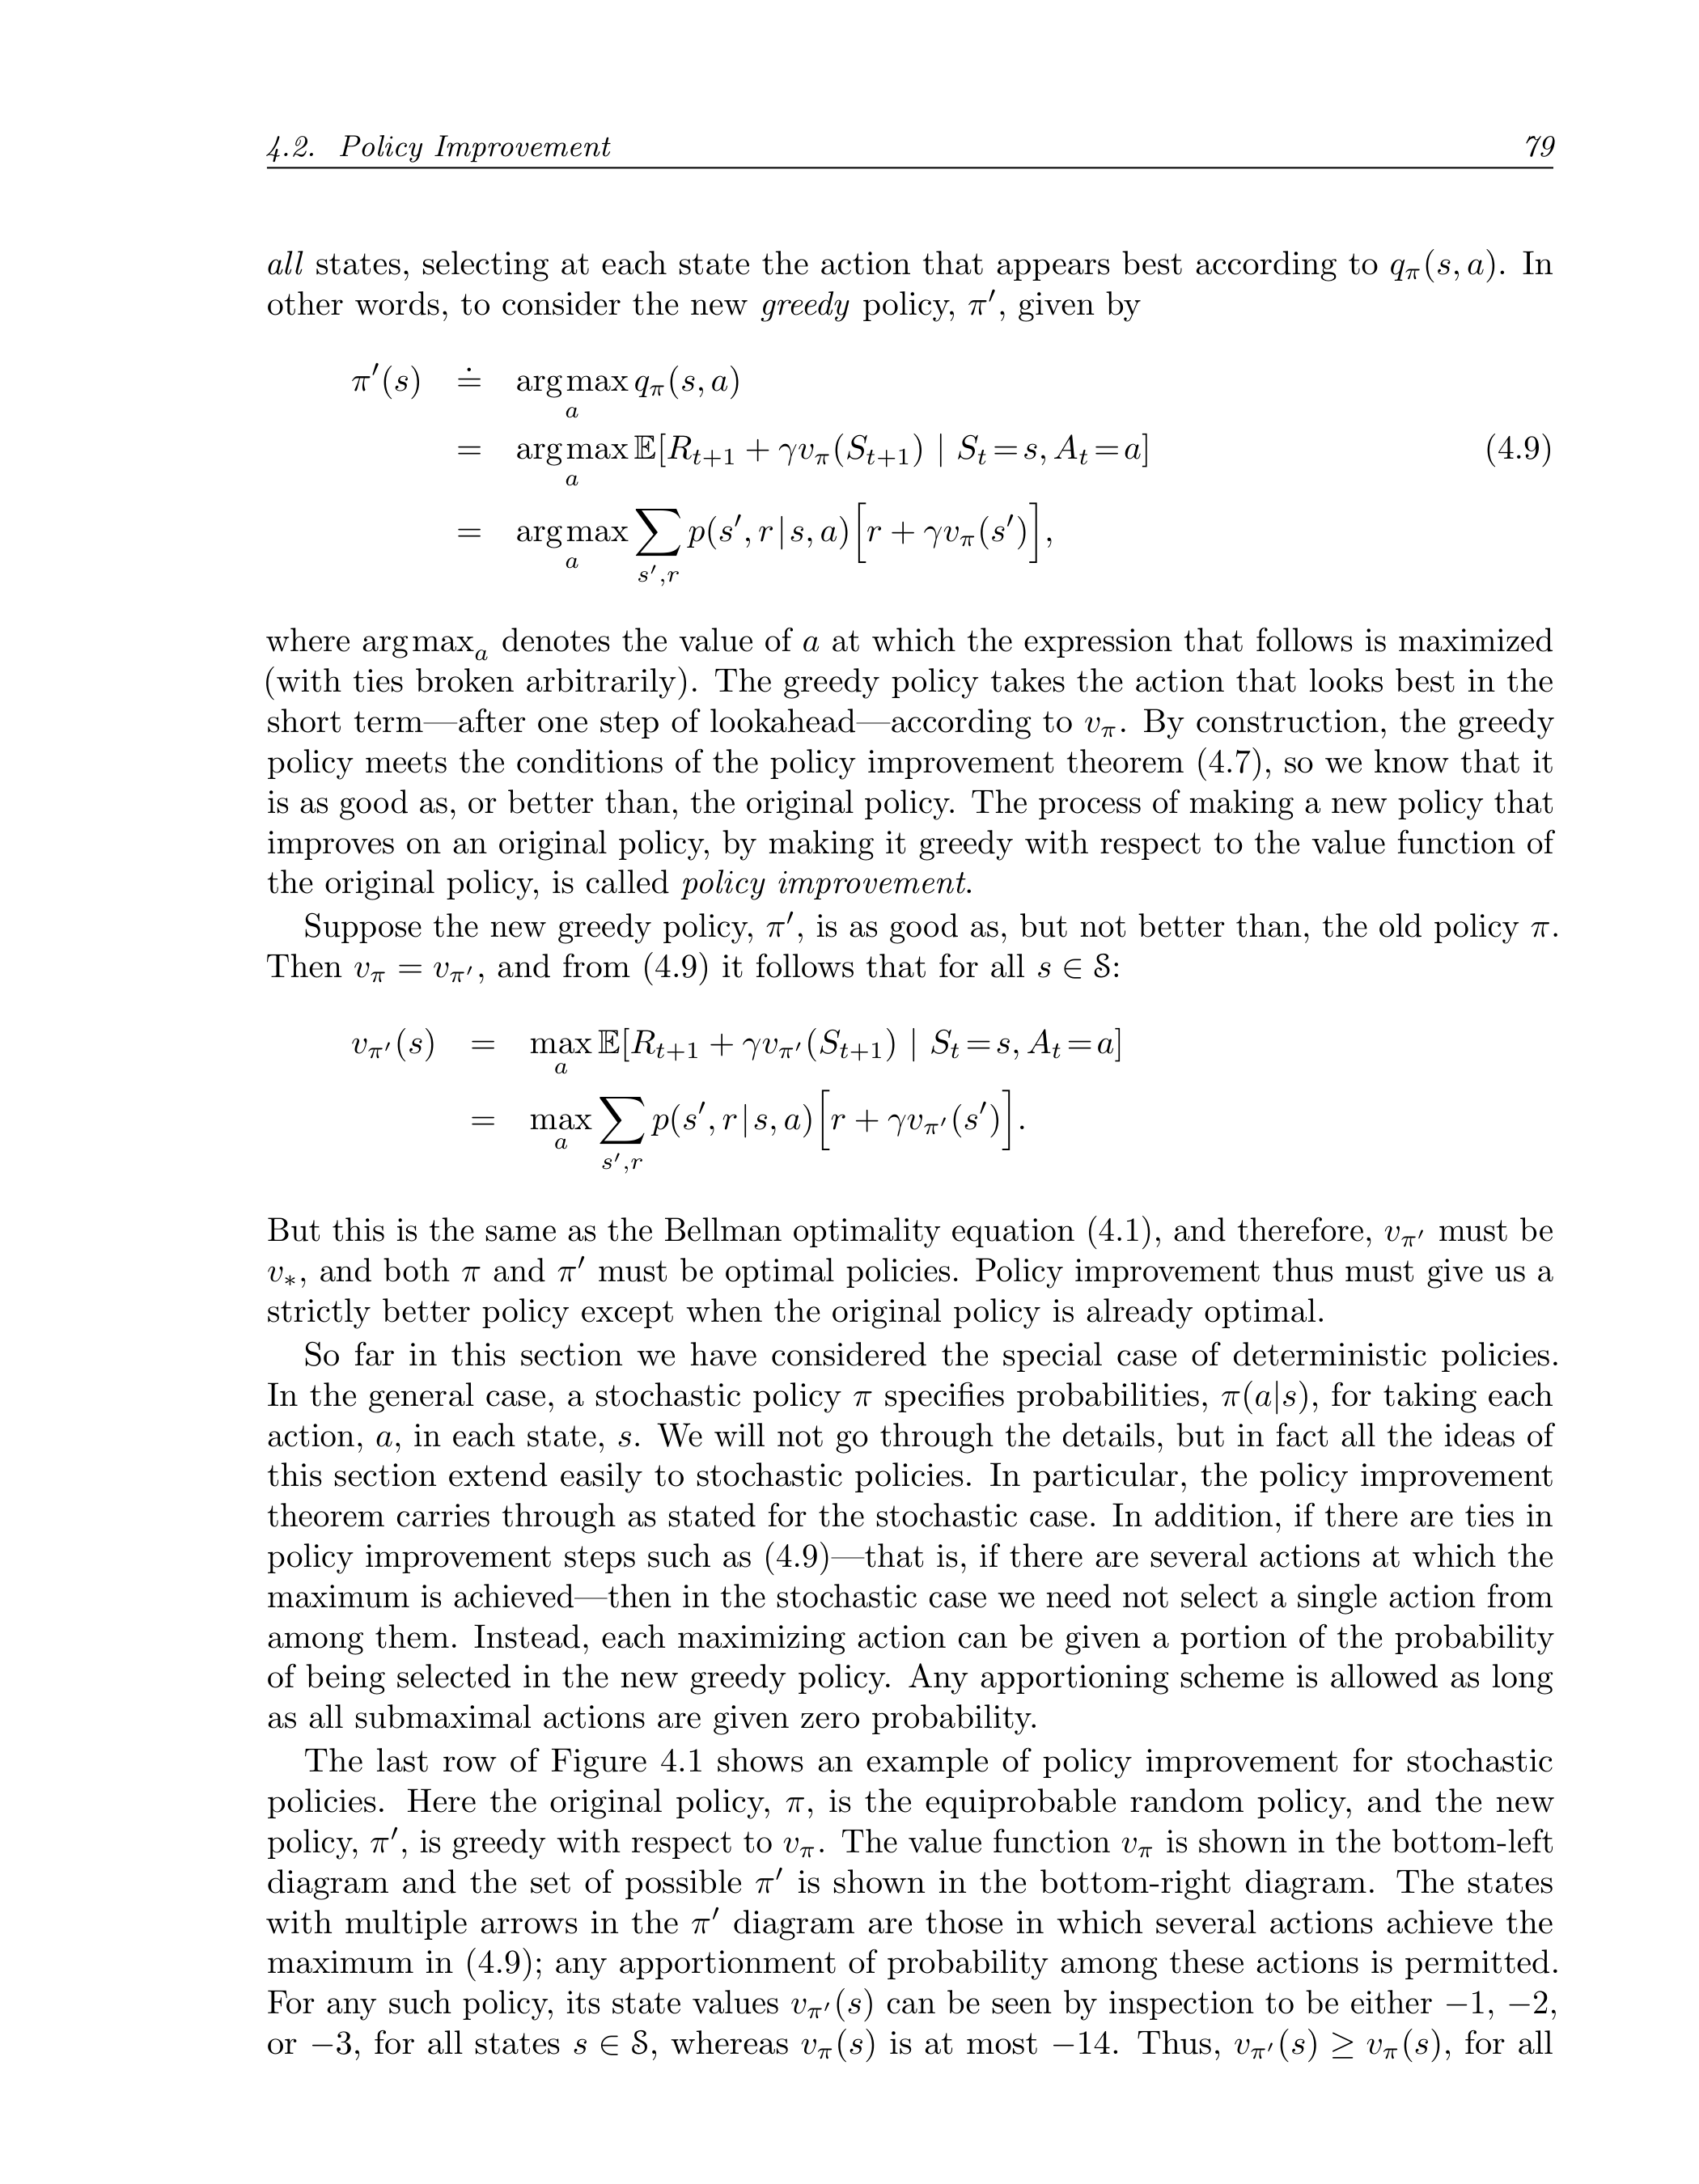

In [20]:
import fitz
from PIL import Image
import io

doc = fitz.open(pdf_path)
page = doc[100]
pix = page.get_pixmap(dpi=300)
img = Image.open(io.BytesIO(pix.tobytes("png")))

img

In [21]:
from PIL import ImageDraw, ImageFont


DETECTION_COLOR = "#2563eb"


def annotate_detection(image, detection_result):
    img = image.convert("RGB").copy()
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 18)
    except Exception:
        font = ImageFont.load_default()

    for box in detection_result.bboxes:
        points = [(int(x), int(y)) for x, y in box.polygon]
        if len(points) < 3:
            continue

        draw.polygon(points, outline=DETECTION_COLOR)

        # PIL polygon outline does not support width, so draw edges manually.
        for idx in range(len(points)):
            p1 = points[idx]
            p2 = points[(idx + 1) % len(points)]
            draw.line([p1, p2], fill=DETECTION_COLOR, width=3)

        text = f"Text {float(box.confidence):.2f}"
        text_bbox = draw.textbbox((0, 0), text, font=font)
        text_w = text_bbox[2] - text_bbox[0]
        text_h = text_bbox[3] - text_bbox[1]

        text_x, text_y = points[0]
        text_y = max(0, text_y - text_h - 8)

        draw.rectangle(
            [
                (text_x, text_y),
                (text_x + text_w + 8, text_y + text_h + 4),
            ],
            fill=DETECTION_COLOR,
        )
        draw.text((text_x + 4, text_y + 2), text, fill="white", font=font)

    return img


In [22]:
detection = dp([img])

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  3.30it/s]


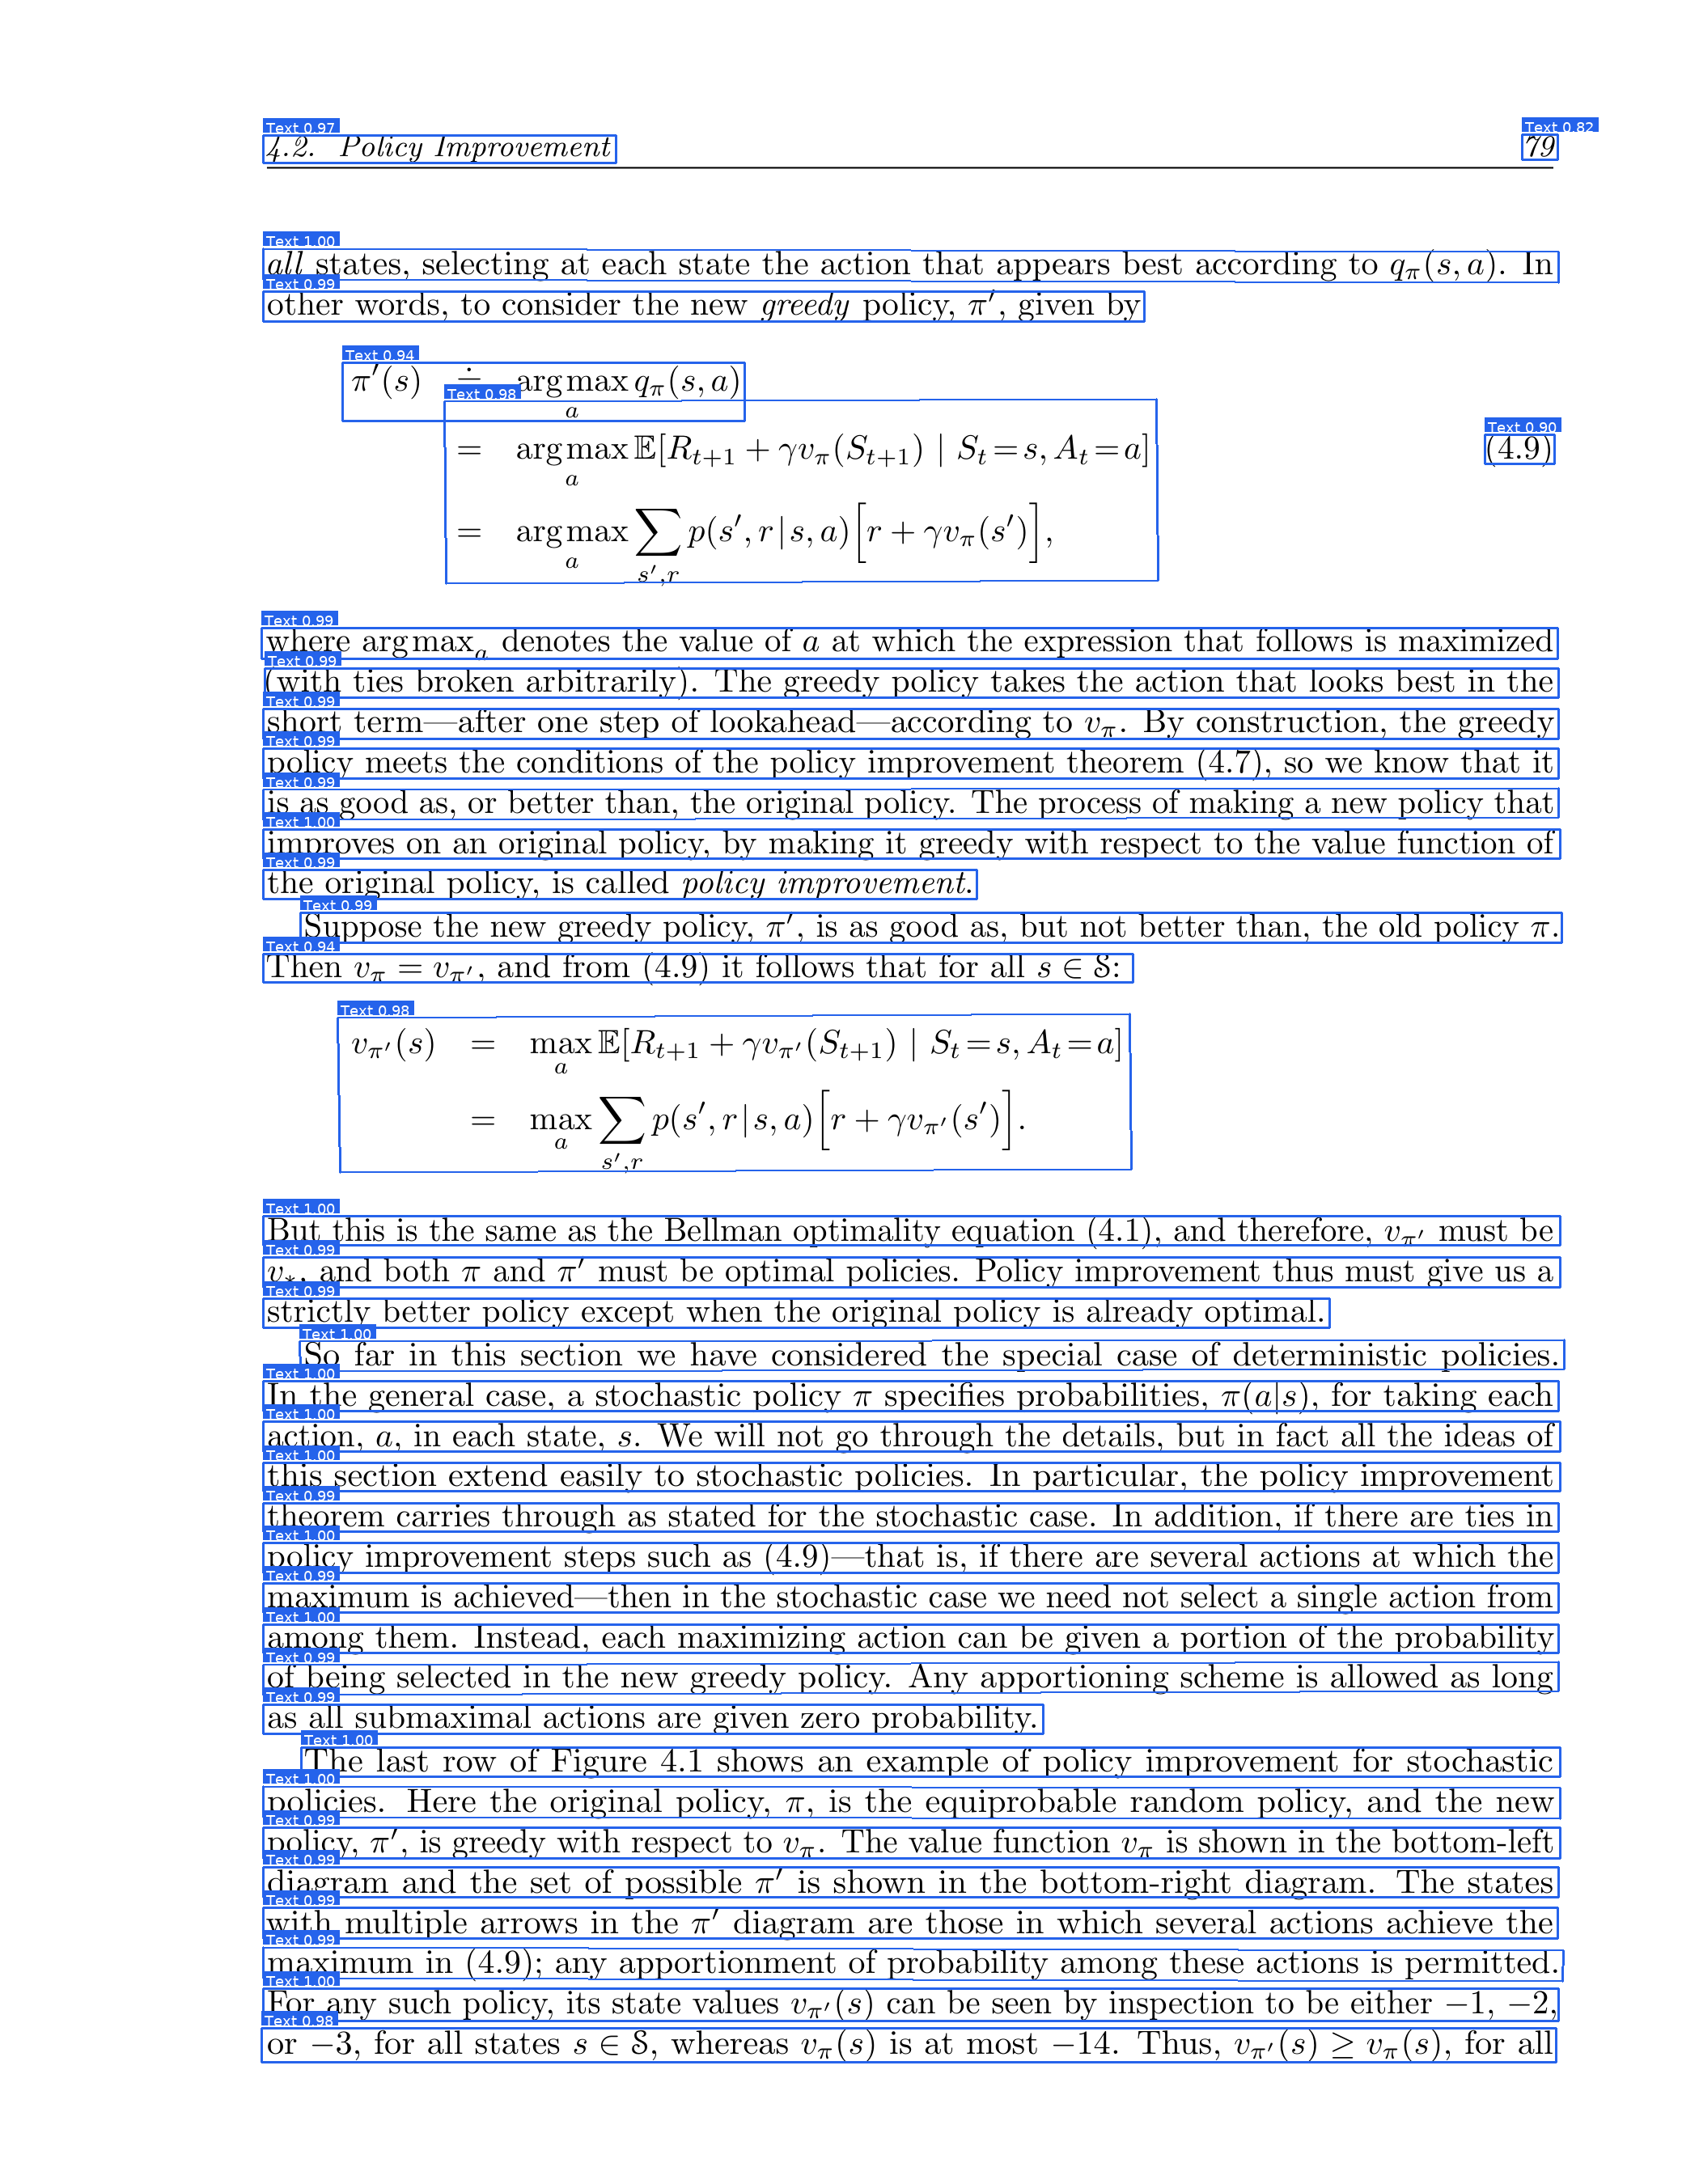

In [26]:
annotated_detection = annotate_detection(img, detection[0])

annotated_detection

In [23]:
import rich
rich.print(detection)

[
    TextDetectionResult(
        bboxes=[
            PolygonBox(
                polygon=[[1881, 166], [1925, 166], [1925, 197], [1881, 197]],
                confidence=0.8185929656028748,
                bbox=[1881, 166, 1925, 197]
            ),
            PolygonBox(
                polygon=[[325, 167], [761, 167], [761, 201], [325, 201]],
                confidence=0.9713568091392517,
                bbox=[325, 167, 761, 201]
            ),
            PolygonBox(
                polygon=[[325, 307], [1926, 311], [1926, 349], [325, 345]],
                confidence=0.995979905128479,
                bbox=[325, 307, 1926, 349]
            ),
            PolygonBox(
                polygon=[[325, 360], [1414, 360], [1414, 397], [325, 397]],
                confidence=0.9894472360610962,
                bbox=[325, 360, 1414, 397]
            ),
            PolygonBox(
                polygon=[[423, 448], [920, 448], [920, 520], [423, 520]],
                confidence=0.9407035112380981,
                bbox=[423, 448, 920, 520]
            ),
            PolygonBox(
                polygon=[[549, 496], [1429, 493], [1431, 717], [551, 721]],
                confidence=0.9814070463180542,
                bbox=[549, 493, 1431, 721]
            ),
            PolygonBox(
                polygon=[[1835, 537], [1921, 537], [1921, 573], [1835, 573]],
                confidence=0.9020100235939026,
                bbox=[1835, 537, 1921, 573]
            ),
            PolygonBox(
                polygon=[[323, 776], [1925, 776], [1925, 814], [323, 814]],
                confidence=0.9899497628211975,
                bbox=[323, 776, 1925, 814]
            ),
            PolygonBox(
                polygon=[[327, 826], [1926, 826], [1926, 862], [327, 862]],
                confidence=0.987939715385437,
                bbox=[327, 826, 1926, 862]
            ),
            PolygonBox(
                polygon=[[325, 876], [1926, 876], [1926, 913], [325, 913]],
                confidence=0.9894472360610962,
                bbox=[325, 876, 1926, 913]
            ),
            PolygonBox(
                polygon=[[325, 925], [1926, 925], [1926, 962], [325, 962]],
                confidence=0.9884421825408936,
                bbox=[325, 925, 1926, 962]
            ),
            PolygonBox(
                polygon=[[325, 976], [1926, 974], [1926, 1010], [325, 1013]],
                confidence=0.9894472360610962,
                bbox=[325, 974, 1926, 1013]
            ),
            PolygonBox(
                polygon=[[325, 1025], [1928, 1025], [1928, 1061], [325, 1061]],
                confidence=0.995979905128479,
                bbox=[325, 1025, 1928, 1061]
            ),
            PolygonBox(
                polygon=[[325, 1075], [1207, 1075], [1207, 1111], [325, 1111]],
                confidence=0.9909547567367554,
                bbox=[325, 1075, 1207, 1111]
            ),
            PolygonBox(
                polygon=[[371, 1128], [1930, 1128], [1930, 1165], [371, 1165]],
                confidence=0.9859296679496765,
                bbox=[371, 1128, 1930, 1165]
            ),
            PolygonBox(
                polygon=[[325, 1179], [1400, 1179], [1400, 1214], [325, 1214]],
                confidence=0.9427135586738586,
                bbox=[325, 1179, 1400, 1214]
            ),
            PolygonBox(
                polygon=[[417, 1258], [1396, 1253], [1398, 1445], [420, 1449]],
                confidence=0.9829145669937134,
                bbox=[417, 1253, 1398, 1449]
            ),
            PolygonBox(
                polygon=[[325, 1503], [1928, 1503], [1928, 1539], [325, 1539]],
                confidence=0.9969848990440369,
                bbox=[325, 1503, 1928, 1539]
            ),
            PolygonBox(
                polygon=[[325, 1554], [1928, 1554], [1928, 1591], [325, 1591]],
                confidence=0.9939698576927185,
                bbox=[325, 1554, 1928, 1591]
            ),
            Polygon